# US Equities Panel: Feasibility Analysis

This notebook tests whether the broad US equities dataset (~3,200 stocks, daily,
1990--2018) can deliver on the strategy declared in `config/setup.yaml`. The YAML
is the canonical, hand-curated source of truth: universe size, costs (era-
dependent), decision cadence, mapping class, labels, sweep grid, evaluation
protocol, and kill conditions. This notebook does not write it. It produces the
evidence that justifies its values: universe breadth, return distributions vs
era-dependent costs, walk-forward fold structure, and an edge-to-cost ratio.
Findings persist to `config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify the data delivers what `setup.yaml` assumes (breadth, costs, holdout)
- Document survivorship handling and point-in-time membership for cross-sectional equities
- Test whether typical daily/weekly/monthly moves exceed costs in the era-dependent regime
- Demonstrate the walk-forward structure has adequate breadth per fold
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2--6.6

## Prerequisites

- US equities data available via `load_us_equities()` (survivorship-bias free,
  includes delisted up to delist date)
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of walk-forward cross-validation (Section 6.5)

In [1]:
"""US Equities Panel: Feasibility Analysis."""

import json
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml
from scipy import stats

from data import load_us_equities
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
CASE_STUDY_ID = "us_equities_panel"
START_DATE = "1990-01-01"
MAX_SYMBOLS = 0

## Configuration

In [3]:
CASE_DIR = get_case_study_dir("us_equities_panel")
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
START_DATE = "1990-01-01"
END_DATE = "2018-03-31"  # Wiki Prices US equities data ends Q1 2018
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])

# Era boundary: decimalization (NYSE/AMEX 2001-01-29; NASDAQ 2001-04-09).
DECIMALIZATION_DATE = "2001-01-29"

---

## Section A: Orientation (Section 6.2)

Broad US equities at daily frequency are the workhorse dataset of academic
cross-sectional asset pricing. The Wiki Prices archive (1962--2018) is
survivorship-bias-free: delisted stocks remain in the panel until their delist
date. We restrict to 1990--2018 (28 years) for modern microstructure relevance
and to align with the decimalization era split (pre/post 2001-01-29).

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Is breadth (~3,000 names per day) adequate for decile sorting?
- **Costs**: Do typical daily moves exceed era-dependent transaction costs
  (15--30 bps RT pre-decimalization, 5--15 bps RT post)?
- **Evaluation**: Do 16 annual walk-forward folds (1990--2015) each carry
  enough cross-sectional breadth?
- **Holdout**: Is the holdout (2016-01-01 to 2018-03-31) cleanly separated from
  training data?

---

## Section B: Universe and Cost Feasibility (Sections 6.3--6.4)

### B.1 Load and Explore the Data

In [4]:
equities = load_us_equities(start_date=START_DATE, end_date=END_DATE)

n_symbols = equities["symbol"].n_unique()
n_dates = equities["timestamp"].n_unique()
avg_stocks_per_day = len(equities) // max(n_dates, 1)

print(f"Loaded US equities: {n_symbols:,} stocks, {n_dates:,} trading days")
print(f"  Period: {equities['timestamp'].min()} to {equities['timestamp'].max()}")
print(f"  Avg stocks per day: {avg_stocks_per_day:,}")

Loaded US equities: 3,199 stocks, 7,234 trading days
  Period: 1990-01-02 to 2018-03-27
  Avg stocks per day: 2,004


**Note**: `load_us_equities()` returns split-adjusted close prices. The panel is
survivorship-bias-free: each stock is present from its first trading day until
its delist date (or end of sample). Delisted stocks contribute to early folds
and disappear thereafter, which is the correct point-in-time behavior.

### B.2 Universe Composition Over Time

Cross-sectional equity strategies require careful universe construction:

- **Survivorship handling**: include delisted stocks until their delist date
  (the Wiki Prices archive does this natively; no further work needed).
- **Membership rule**: at each decision date, use only stocks present in the
  panel as of that date --- never filter on end-of-sample availability.
- **Liquidity / price filters**: apply at decision time, not retroactively.
  `setup.yaml::universe.n_assets = 3199` counts the full panel; downstream
  notebooks apply price > \$5 and ADV > \$1M filters at decision time.

In [5]:
# Annual breadth: how many distinct stocks appeared in each year?
annual_breadth = (
    equities.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("symbol").n_unique().alias("n_stocks"))
    .sort("year")
)
print("Annual universe breadth (distinct stocks per calendar year):")
annual_breadth

Annual universe breadth (distinct stocks per calendar year):


year,n_stocks
i32,u32
1990,791
1991,869
1992,1030
1993,1164
1994,1251
…,…
2014,3163
2015,3073
2016,2883


#### Sample-Date Eligibility Demonstration

To illustrate the price filter at decision time, we apply price > \$5 on the
last available date. Downstream notebooks materialize this filter daily.

In [6]:
sample_date = equities["timestamp"].max()
day_data = equities.filter(pl.col("timestamp") == sample_date)
price_eligible = day_data.filter(pl.col("close") > 5.0)

print(f"Eligibility at {sample_date} (illustrative):")
print(f"  Total stocks present:        {len(day_data):,}")
print(f"  After price > $5 filter:     {len(price_eligible):,}")
print(f"  Penny stocks excluded:       {len(day_data) - len(price_eligible):,}")

Eligibility at 2018-03-27 (illustrative):
  Total stocks present:        2,422
  After price > $5 filter:     2,206
  Penny stocks excluded:       216


### B.3 Trading Cost Analysis: Era-Dependent Horizon Feasibility

`setup.yaml::costs` declares an era-dependent cost model:

- **Pre-decimalization (before 2001-01-29)**: 15--30 bps per leg (30--60 bps RT).
  Tick size of $1/16$ ($0.0625$) widened spreads; commissions were ~3--5 cents/share.
- **Post-decimalization (2001-01-29 onward)**: 5--15 bps per leg (10--30 bps RT).
  Penny tick regime; electronic trading collapsed spreads.

A long-short overlay further requires borrow on the short leg (~50 bps/yr).

**Key question**: at which horizons do typical equity price moves exceed costs
in each era?

**Sampling note**: we sample by symbol (not by row) to preserve per-symbol time
continuity. Row-level sampling would create spurious multi-day gaps and inflate
return magnitudes. We restrict to the pre-holdout period.

In [7]:
holdout_start_dt = pl.lit(HOLDOUT_START).str.to_date()
decimalization_dt = pl.lit(DECIMALIZATION_DATE).str.to_date()

pre_holdout = equities.filter(pl.col("timestamp") < holdout_start_dt)

unique_symbols = pre_holdout.select("symbol").unique()
n_sample_symbols = min(500, len(unique_symbols))
sample_symbols = unique_symbols.sample(n=n_sample_symbols, seed=42)["symbol"].to_list()
sample_equities = pre_holdout.filter(pl.col("symbol").is_in(sample_symbols))

print(f"Sampled {n_sample_symbols} symbols for horizon analysis (pre-holdout only)")

Sampled 500 symbols for horizon analysis (pre-holdout only)


In [8]:
# Daily returns with gap guard (drop returns spanning >5 calendar days)
daily_returns = (
    sample_equities.sort(["symbol", "timestamp"])
    .with_columns(
        [
            (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return"),
            (pl.col("timestamp") - pl.col("timestamp").shift(1)).over("symbol").alias("date_delta"),
        ]
    )
    .filter(pl.col("return").is_not_null())
    .filter(pl.col("date_delta").dt.total_days() <= 5)
    .select(["symbol", "timestamp", "return"])
)

# Weekly returns
weekly_data = (
    sample_equities.with_columns(pl.col("timestamp").dt.strftime("%G-W%V").alias("week"))
    .group_by(["symbol", "week"])
    .agg(pl.col("close").last().alias("close"), pl.col("timestamp").max().alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
weekly_returns = (
    weekly_data.with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
    )
    .filter(pl.col("return").is_not_null())
    .select(["symbol", "timestamp", "return"])
)

# Monthly returns
monthly_data = (
    sample_equities.with_columns(pl.col("timestamp").dt.strftime("%Y-%m").alias("month"))
    .group_by(["symbol", "month"])
    .agg(pl.col("close").last().alias("close"), pl.col("timestamp").max().alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
monthly_returns = (
    monthly_data.with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
    )
    .filter(pl.col("return").is_not_null())
    .select(["symbol", "timestamp", "return"])
)

print(f"Daily returns:   {len(daily_returns):,} observations")
print(f"Weekly returns:  {len(weekly_returns):,} observations")
print(f"Monthly returns: {len(monthly_returns):,} observations")

Daily returns:   2,055,263 observations
Weekly returns:  425,838 observations
Monthly returns: 97,703 observations


#### Cost Exceedance by Era

We split each return series into pre- and post-decimalization observations and
report the fraction exceeding the era-specific round-trip cost midpoint.

In [9]:
decimalization_dt_py = pl.Series([DECIMALIZATION_DATE]).str.to_date("%Y-%m-%d").item()

# Era midpoints from setup.yaml::costs.era_dependent.per_leg_cost_bps_range
PRE_LEG_BPS_MID = (15 + 30) / 2  # 22.5
POST_LEG_BPS_MID = (5 + 15) / 2  # 10
PRE_RT_COST = (2 * PRE_LEG_BPS_MID) / 10_000  # 0.0045
POST_RT_COST = (2 * POST_LEG_BPS_MID) / 10_000  # 0.0020


def split_by_era(ret_df: pl.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    pre = ret_df.filter(pl.col("timestamp") < decimalization_dt_py)["return"].abs().to_numpy()
    post = ret_df.filter(pl.col("timestamp") >= decimalization_dt_py)["return"].abs().to_numpy()
    return pre, post


daily_pre, daily_post = split_by_era(daily_returns)
weekly_pre, weekly_post = split_by_era(weekly_returns)
monthly_pre, monthly_post = split_by_era(monthly_returns)

era_rows = []
for label, pre_arr, post_arr in [
    ("Daily", daily_pre, daily_post),
    ("Weekly", weekly_pre, weekly_post),
    ("Monthly", monthly_pre, monthly_post),
]:
    era_rows.append(
        {
            "horizon": label,
            "n_pre": int(len(pre_arr)),
            "n_post": int(len(post_arr)),
            "median_pre_bps": float(np.median(pre_arr) * 10_000) if len(pre_arr) else float("nan"),
            "median_post_bps": float(np.median(post_arr) * 10_000)
            if len(post_arr)
            else float("nan"),
            "pct_pre_above_pre_rt": float((pre_arr > PRE_RT_COST).mean() * 100)
            if len(pre_arr)
            else float("nan"),
            "pct_post_above_post_rt": float((post_arr > POST_RT_COST).mean() * 100)
            if len(post_arr)
            else float("nan"),
        }
    )

era_df = pl.DataFrame(era_rows)
print(
    f"Pre-decimal RT midpoint: {PRE_RT_COST * 10_000:.0f} bps   "
    f"Post-decimal RT midpoint: {POST_RT_COST * 10_000:.0f} bps"
)
era_df

Pre-decimal RT midpoint: 45 bps   Post-decimal RT midpoint: 20 bps


horizon,n_pre,n_post,median_pre_bps,median_post_bps,pct_pre_above_pre_rt,pct_post_above_post_rt
str,i64,i64,f64,f64,f64,f64
"""Daily""",568933,1486330,126.582278,119.331742,73.7477,87.958596
"""Weekly""",117486,308352,288.372093,276.243094,87.97644,94.914254
"""Monthly""",26597,71106,643.478261,607.033912,94.71369,97.769527


#### Pooled Return Distributions by Horizon

A second view: pooled across both eras (this matches how the YAML cost grid in
`backtest.sweep.cost_grid_bps: [0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50]` is
applied to the full holdout). Cost reference is 10 bps RT (the post-decimal
midpoint), which is binding for most of the test sample.

In [10]:
daily_abs = daily_returns["return"].abs().to_numpy()
weekly_abs = weekly_returns["return"].abs().to_numpy()
monthly_abs = monthly_returns["return"].abs().to_numpy()

POOLED_RT_COST = 0.0010  # 10 bps RT (post-decimal midpoint)

pooled_rows = []
for label, arr in [("Daily", daily_abs), ("Weekly", weekly_abs), ("Monthly", monthly_abs)]:
    pooled_rows.append(
        {
            "horizon": label,
            "median_abs_bps": float(np.median(arr) * 10_000),
            "pct_exceed_10bps": float((arr > POOLED_RT_COST).mean() * 100),
            "move_cost_ratio": float(np.median(arr) / POOLED_RT_COST),
        }
    )
pooled_df = pl.DataFrame(pooled_rows)
print("Pooled (1990--2015) absolute-return summary, cost ref 10 bps RT:")
pooled_df

Pooled (1990--2015) absolute-return summary, cost ref 10 bps RT:


horizon,median_abs_bps,pct_exceed_10bps,move_cost_ratio
str,f64,f64,f64
"""Daily""",120.967742,89.589799,12.096774
"""Weekly""",279.204658,95.478562,27.920466
"""Monthly""",616.438356,98.055331,61.643836


#### Visualize Return Distributions

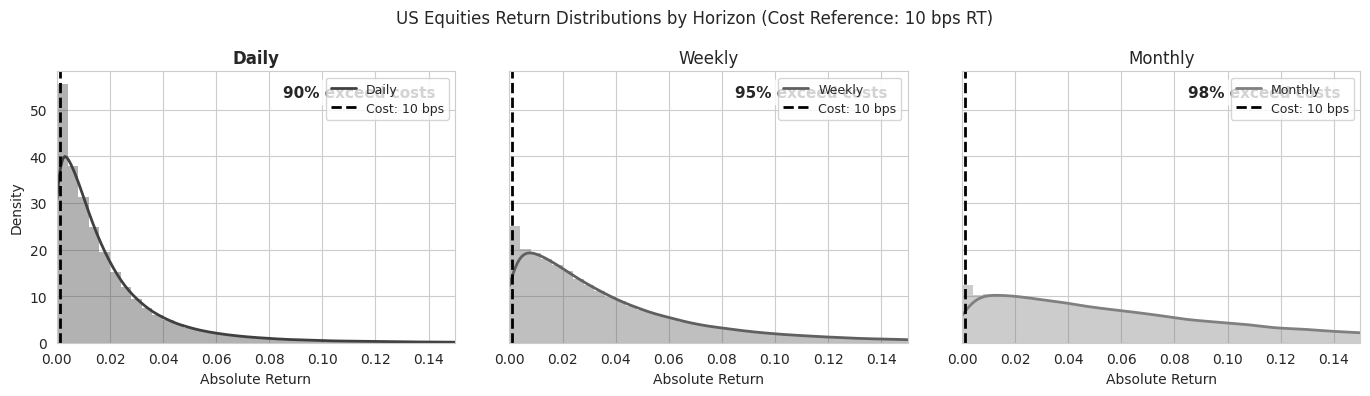

In [11]:
GRAY_COLORS = ["#404040", "#606060", "#808080"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

horizons = [
    ("Daily", daily_abs, GRAY_COLORS[0]),
    ("Weekly", weekly_abs, GRAY_COLORS[1]),
    ("Monthly", monthly_abs, GRAY_COLORS[2]),
]

for ax, (label, data, color) in zip(axes, horizons, strict=False):
    data_clipped = data[data < 0.20]
    if len(data_clipped) == 0:
        continue
    bin_edges = np.linspace(float(data_clipped.min()), float(data_clipped.max()), 51)
    ax.hist(data_clipped, bins=bin_edges, density=True, alpha=0.4, color=color, edgecolor="none")
    if len(data_clipped) > 100:
        kde = stats.gaussian_kde(data_clipped, bw_method=0.1)
        x_grid = np.linspace(0, 0.15, 200)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2, label=f"{label}")
    ax.axvline(POOLED_RT_COST, color="black", linestyle="--", linewidth=2, label="Cost: 10 bps")
    frac_above = (data > POOLED_RT_COST).mean()
    ax.text(
        0.95,
        0.95,
        f"{frac_above:.0%} exceed costs",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )
    ax.set_title(label, fontweight="bold" if label == "Daily" else "normal")
    ax.set_xlabel("Absolute Return")
    ax.set_xlim(0, 0.15)
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Density")
fig.suptitle("US Equities Return Distributions by Horizon (Cost Reference: 10 bps RT)")
fig.tight_layout()
plt.show()

#### Interpretation

- **Daily (marginal pre-2001, comfortable post)**: Median absolute daily move
  exceeds the 10 bps post-decimal floor by a healthy margin; in the pre-2001
  regime (15--30 bps/leg), daily strategies are far more marginal --- only
  large-caps clear the 45 bps RT threshold.
- **Weekly**: Comfortable in both eras. Loses resolution for short-horizon
  effects like reversal but adds cost headroom.
- **Monthly**: Costs are clearly not binding. Captures slow signals (12-1
  momentum, value).

**Liquidity caveat**: small-caps incur substantially higher per-leg costs (15--20
bps post-decimal). For strategies that trade into small-caps, the 10 bps cost
reference understates the actual friction --- daily becomes marginal or infeasible.

### B.4 Cost-Regime Choice: bps Aggregate, Not per-Share

`setup.yaml::costs.model = percentage` — costs are declared in basis points
rather than a flat $/share half-spread. The reason is that this panel covers
1990--2015 across ~3,000 stocks, and a flat $/share number does not survive
either dimension.

In [12]:
sample_holdout_prices = sample_equities.filter(
    (pl.col("timestamp") >= decimalization_dt_py)
    & pl.col("close").is_not_null()
    & (pl.col("close") > 0)
)["close"].to_numpy()
HALF_SPREAD_USD = 0.025  # 2.5¢/share = $0.025, a common penny-tick proxy
implied_half_spread_bps = (HALF_SPREAD_USD / np.median(sample_holdout_prices)) * 10_000
implied_round_trip_bps = 2 * implied_half_spread_bps
price_p10 = float(np.quantile(sample_holdout_prices, 0.10))
price_p90 = float(np.quantile(sample_holdout_prices, 0.90))
print(
    f"Post-decimal sample price distribution: "
    f"p10=${price_p10:.2f}, median=${np.median(sample_holdout_prices):.2f}, p90=${price_p90:.2f}"
)
print(
    f"Flat 2.5¢ half-spread at median price → {implied_half_spread_bps:.0f} bps/leg, "
    f"{implied_round_trip_bps:.0f} bps RT"
)
print(
    f"  at p10 price ${price_p10:.2f} → {(HALF_SPREAD_USD / price_p10) * 10_000:.0f} bps/leg "
    f"({2 * (HALF_SPREAD_USD / price_p10) * 10_000:.0f} bps RT)"
)
print(
    f"  at p90 price ${price_p90:.2f} → {(HALF_SPREAD_USD / price_p90) * 10_000:.0f} bps/leg "
    f"({2 * (HALF_SPREAD_USD / price_p90) * 10_000:.0f} bps RT)"
)

Post-decimal sample price distribution: p10=$4.85, median=$22.56, p90=$63.50
Flat 2.5¢ half-spread at median price → 11 bps/leg, 22 bps RT
  at p10 price $4.85 → 52 bps/leg (103 bps RT)
  at p90 price $63.50 → 4 bps/leg (8 bps RT)


**The disagreement is the lesson.** A uniform 2.5¢ half-spread looks
reasonable from a penny-tick microstructure prior, but split-adjusted prices
in this panel sit between $5 and $20 for much of the sample. At the p10
price the same 2.5¢ implies a round-trip cost approaching 100 bps;
the bps regime at a realistic 5--15 bps/leg implies a manageable 20--60 bps
round-trip. Neither regime is perfect, but bps is the more defensible
aggregate over a 25-year wide-universe panel where liquidity drifts by
orders of magnitude (pre-2001 quarter-tick widening spreads; post-2001
penny-tick + electronic execution).

Better data would dominate either regime: historical NBBO half-spreads at
panel scale (TAQ vendor with split-adjusted alignment) would let the
engine join per-asset-per-date measured costs the same way
`nasdaq100_microstructure` joins AlgoSeek minute-bar NBBO. Until such a
panel is available, the bps regime is the constraint-aware default; the
`per_share_plus_spread` companion regime in
`setup.yaml::backtest.sweep.cost_grid_half_spread_usd` is
preserved as a cost-sensitivity check so the cost notebook can show how
brittle the strategy is when the assumption flips.

**Structural regimes and adjusted-price confounders.** Three deeper
uncertainties layer underneath the bps-vs-per-share decision and warrant
explicit acknowledgement before any cost number is read as a forecast:

1. **Decimalization (2001-01-29).** Pre-decimal US equities quoted in
   fractional ticks ($0.0625 / $0.03125 / $0.01563 floors); the minimum
   spread was wider mechanically, and realized spreads were typically
   wider still. Post-decimal penny ticks plus electronic execution
   compressed both. The validation window starts 2000-01-12, so the
   pre-decimal portion is ~13 months out of ~16 years — roughly 6.5% of
   the window. The era-aware ranges declared in
   `setup.yaml::costs.era_dependent` document the qualitative split; the
   loader reads only the top-level `per_leg_cost_bps_range` and runs a
   flat 12.5 bps/leg midpoint throughout. Given the small pre-decimal
   share, the flat midpoint is acceptable as an aggregate; calling out
   the era split here is enough.

2. **Adjusted-price confounder.** Prices in this panel are
   split-adjusted. A flat $0.025/share half-spread quoted in *current*
   dollars applied to a *historical adjusted* price implies a different
   bps friction than the same $0.025 applied to the unadjusted nominal
   that actually traded. In the 2000--2015 window the median
   `close / adj_close` factor is ~1.0--1.5× — meaningful but bounded.
   Going further back is where this bites: 1990s median ≈3×, 1980s ≈8×,
   pre-1980s much higher. Those eras are outside our backtest window;
   the confounder is modest here but a strict per-share regime would
   still distort the early-2000s portion meaningfully.

3. **Structurally different market regimes.** Decimalization (2001),
   Regulation NMS (2007), the rise of high-frequency market making, and
   retail zero-commission brokerages (2019) each restructured the
   microstructure under which alpha can be extracted. Even with perfect
   cost modeling, a 25-year backtest is testing whether a strategy
   worked in markets that no longer exist in the same form — not
   forecasting forward performance. Accurate historical simulation is
   non-trivial in adjacent asset classes too: faithful CME-style
   futures margin requires the historical span margin table direct from
   CME ($50k/yr commercial product), and historical equity NBBO across
   a panel of this breadth would require a TAQ vendor with
   split-adjusted alignment. For the post-2001 window our flat bps grid
   covers the realistic envelope of execution friction; the structural
   decay across regimes is the residual uncertainty that no in-sample
   sensitivity sweep can quantify away.

### B.5 Feasibility Ratio (Primary Label Horizon)

The primary label is `fwd_ret_1d` (daily; `setup.yaml::labels.primary`). The
simplest gate: does the typical daily move exceed the post-decimal round-trip
cost?

In [13]:
median_daily_abs = float(np.median(daily_abs))
feasibility_ratio_daily = median_daily_abs / POOLED_RT_COST
print(f"Median daily |return|: {median_daily_abs:.5f} ({median_daily_abs * 10_000:.1f} bps)")
print(f"Post-decimal RT cost: {POOLED_RT_COST:.4f} ({POOLED_RT_COST * 10_000:.0f} bps)")
print(f"Daily edge-to-cost ratio: {feasibility_ratio_daily:.1f}x")
print(f"Assessment: {'PROCEED' if feasibility_ratio_daily > 1.0 else 'KILL -- edge too thin'}")

Median daily |return|: 0.01210 (121.0 bps)
Post-decimal RT cost: 0.0010 (10 bps)
Daily edge-to-cost ratio: 12.1x
Assessment: PROCEED


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml`. They are
justified here in prose; the YAML is the canonical, hand-curated source of truth.

### C.1 Decision Cadence

`setup.yaml::decision.cadence: daily_close` --- snapshot at the close, execute at
the next bar open (`execution_delay: next_bar_open`). Daily cadence is the
conventional choice for broad cross-sectional equity studies because:

- The primary label `fwd_ret_1d` aligns mechanically with daily decisions.
- Daily breadth (~3,000 stocks) supports decile sorting with ample N per bucket.
- The thinning step (`labels.rebalance_step.fwd_ret_1d = 1`) means the
  vectorized backtest does not skip schedule slots --- every trading day is a
  decision date.

Weekly (5d) and monthly (21d) horizons are exposed as label variants
(`labels.variants: [fwd_ret_5d, fwd_ret_21d]`) with matching `rebalance_step`
values so longer-horizon strategies hold positions for their label horizon.

### C.2 Kill Conditions

`setup.yaml::kill_conditions` declares falsifiable checkpoints. If any triggers,
the strategy is abandoned or substantially reworked. The thresholds are anchored
to the feasibility evidence above and to long-short equity literature:

- **IC floor** (`ic_floor: 0.01`): cross-sectional IC below 0.01 across all
  features. Gate: Chapter 8 feature evaluation.
- **Edge-to-cost floor** (`edge_to_cost_floor: 1.2`): net Sharpe / cost ratio
  below 1.2x. Gate: Chapter 18 cost analysis. B.5 above tests an upstream
  version of this gate on raw return magnitudes pre-model.
- **Micro-cap concentration** (`micro_cap_concentration: 0.5`): alpha
  concentrated >50% in the bottom-ADV quintile (untradeable at scale).
- **Net Sharpe floor** (`net_sharpe_floor: 0.3`): net Sharpe after borrow costs
  below 0.3. Gate: Chapter 19 risk-overlay analysis.

These are uniquely retained in this CS's YAML because only `20_strategy_analysis`
consumes them; for other case studies they live in prose / report templates.

### C.3 Mapping Class

`setup.yaml::mapping.class: long_short_decile_rebalance` ---
`position_state_space: long_short`, `entry_logic: decile_sort_long_top_short_bottom`,
`sizing: equal_weight_within_decile`. The reasoning:

- **Long-short**: broad US equities are the canonical setting for long-short
  factor strategies. Short borrow is generally available for the large/mid-cap
  subset most strategies touch, at ~50 bps/yr (encoded in
  `costs.borrow_cost_note`). Long-only would discard the bottom-decile signal
  entirely.
- **Decile sort**: with ~3,000 names per day, decile breadth (~300 per decile)
  is large enough for stable rank-based selection.
- **Equal-weight within decile**: avoids introducing a secondary optimization
  (risk-parity, inverse-vol) that would confound evaluation of the ranking
  signal itself. Chapter 17 sweeps alternative allocators
  (`backtest.sweep.allocators`).

Capacity assumptions used at Chapter 18: max 5% of ADV per position and max
0.1% of market cap per name. These constraints bind hardest for small-cap
strategies; the production cost regime above already prices in borrow.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify the data supports the walk-forward design declared in
`setup.yaml::evaluation`: `n_splits=16`, `train_size=10Y`, `val_size=1Y`,
`holdout_start=2016-01-01`, `holdout_end=2018-03-31`.

### D.1 Effective Sample Size and Data Coverage

In [14]:
n_decision_dates = equities.filter(pl.col("timestamp") < holdout_start_dt)["timestamp"].n_unique()
first_date = equities["timestamp"].min()
last_date = equities["timestamp"].max()
n_years = n_decision_dates / 252

print("Data Coverage:")
print(f"  Period: {first_date} to {last_date}")
print(f"  Pre-holdout decision dates (NYSE days): {n_decision_dates:,}")
print(f"  Approx years pre-holdout: {n_years:.1f}")
print(f"  Holdout: {HOLDOUT_START} to {SETUP['evaluation']['holdout_end']}")

Data Coverage:
  Period: 1990-01-02 to 2018-03-27
  Pre-holdout decision dates (NYSE days): 6,672
  Approx years pre-holdout: 26.5
  Holdout: 2016-01-01 to 2018-03-31


### D.2 Walk-Forward Fold Demonstration

`case_studies/utils/cv_window.py` owns the operational splits; this cell
reproduces the fold boundaries from canonical `setup.yaml` parameters to verify
the data supports the declared design. Each fold has:

- **Train period**: `setup.yaml::evaluation.train_size = 10Y`
- **Test period**: `setup.yaml::evaluation.val_size = 1Y`
- **Purge gap**: 1 day between train end and test start (matches the 1D buffer
  for the daily primary label)

In [15]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
purge_days = 1  # matches setup.yaml::labels.buffer (1D)
train_years = 10
test_years = 1

# Build sorted list of pre-holdout decision dates (daily, NYSE)
pre_holdout_dates = (
    equities.filter(pl.col("timestamp") < holdout_start_dt)
    .select("timestamp")
    .unique()
    .sort("timestamp")["timestamp"]
    .to_list()
)

# Step annually by calendar year: test fold k covers year (1990 + train_years + k)
splits = []
first_year = pre_holdout_dates[0].year
last_pre_holdout_year = pre_holdout_dates[-1].year
test_year = first_year + train_years  # first test year = 2000

while test_year <= last_pre_holdout_year:
    train_start = next((d for d in pre_holdout_dates if d.year == test_year - train_years), None)
    train_end_target_year = test_year - 1
    train_end = next(
        (d for d in reversed(pre_holdout_dates) if d.year == train_end_target_year), None
    )
    test_start = next((d for d in pre_holdout_dates if d.year == test_year), None)
    test_end = next((d for d in reversed(pre_holdout_dates) if d.year == test_year), None)
    if not all([train_start, train_end, test_start, test_end]):
        break
    splits.append(
        {
            "fold": len(splits) + 1,
            "train_start": train_start.strftime("%Y-%m-%d"),
            "train_end": train_end.strftime("%Y-%m-%d"),
            "test_start": test_start.strftime("%Y-%m-%d"),
            "test_end": test_end.strftime("%Y-%m-%d"),
            "purge_days": purge_days,
        }
    )
    test_year += test_years

print(f"Generated {len(splits)} walk-forward folds")

assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
last_test_end = splits[-1]["test_end"]
print(f"Last fold test end: {last_test_end}  |  Holdout start: {HOLDOUT_START}")
assert last_test_end < HOLDOUT_START, (
    f"Last fold ({last_test_end}) overlaps holdout ({HOLDOUT_START})"
)

Generated 16 walk-forward folds


Last fold test end: 2015-12-31  |  Holdout start: 2016-01-01


**Walk-forward fold summary:**

In [16]:
splits_df = pl.DataFrame(splits)
splits_df

fold,train_start,train_end,test_start,test_end,purge_days
i64,str,str,str,str,i64
1,"""1990-01-02""","""1999-12-31""","""2000-01-03""","""2000-12-29""",1
2,"""1991-01-02""","""2000-12-29""","""2001-01-01""","""2001-12-31""",1
3,"""1992-01-02""","""2001-12-31""","""2002-01-02""","""2002-12-31""",1
4,"""1993-01-04""","""2002-12-31""","""2003-01-01""","""2003-12-31""",1
5,"""1994-01-03""","""2003-12-31""","""2004-01-02""","""2004-12-31""",1
…,…,…,…,…,…
12,"""2001-01-01""","""2010-12-31""","""2011-01-03""","""2011-12-30""",1
13,"""2002-01-02""","""2011-12-30""","""2012-01-02""","""2012-12-31""",1
14,"""2003-01-01""","""2012-12-31""","""2013-01-01""","""2013-12-31""",1


#### Universe Breadth per Fold

We verify each fold has adequate cross-sectional breadth by counting distinct
stocks present in each test year. Decile sorting requires reasonable N per
decile; with 1,000+ names per fold, deciles average 100+ stocks each.

In [17]:
fold_breadth = []
for split in splits:
    test_year_int = int(split["test_start"][:4])
    year_data = equities.filter(pl.col("timestamp").dt.year() == test_year_int)
    n_stocks = year_data["symbol"].n_unique()
    fold_breadth.append(
        {
            "fold": split["fold"],
            "test_year": test_year_int,
            "n_stocks": n_stocks,
        }
    )

fold_breadth_df = pl.DataFrame(fold_breadth)
print("Distinct stocks per fold test year:")
fold_breadth_df

Distinct stocks per fold test year:


fold,test_year,n_stocks
i64,i64,i64
1,2000,1892
2,2001,1941
3,2002,1995
4,2003,2055
5,2004,2153
…,…,…
12,2011,2804
13,2012,2923
14,2013,3083


Breadth is comfortable in every fold (well over 1,000 names), and grows over
time as new listings outpace delistings. Even the leanest fold supports decile
sorting with ~100+ names per decile.

---

## Section E: Derived Artifacts

Unlike ETFs, the US equities panel does not require a separate
point-in-time eligibility table: the survivorship-bias-free panel is itself
point-in-time (each stock appears between its first trading day and its delist
date), and downstream notebooks apply the daily price > \$5 / ADV > \$1M
filters at decision time. The only artifact this notebook persists is the
feasibility report (Section F).

---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. Setup.yaml is not regenerated here --- it is the hand-curated
source of truth, and this notebook reads it.

In [18]:
n_stocks_min = int(min(fb["n_stocks"] for fb in fold_breadth))
n_stocks_max = int(max(fb["n_stocks"] for fb in fold_breadth))
n_folds_generated = int(len(splits))

median_d_abs_bps = float(np.median(daily_abs) * 10_000)
median_w_abs_bps = float(np.median(weekly_abs) * 10_000)
median_m_abs_bps = float(np.median(monthly_abs) * 10_000)
frac_d_above_10 = float((daily_abs > POOLED_RT_COST).mean())
frac_w_above_10 = float((weekly_abs > POOLED_RT_COST).mean())
frac_m_above_10 = float((monthly_abs > POOLED_RT_COST).mean())

print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.n_assets = {SETUP['universe']['n_assets']}")
print(f"  -> stocks per fold test year: min={n_stocks_min:,}, max={n_stocks_max:,}")
print(f"  -> avg stocks per day across panel: {avg_stocks_per_day:,}")

print()
print(f"decision.cadence = {SETUP['decision']['cadence']}")
print(
    f"  -> median |daily return| = {median_d_abs_bps:.1f} bps; "
    f"{frac_d_above_10 * 100:.0f}% exceed 10bps RT (post-decimal)"
)

print()
print(f"costs.class = {SETUP['costs']['class']} (era-dependent)")
print(
    f"  -> pre-decimal RT mid = {PRE_RT_COST * 10_000:.0f} bps; "
    f"post-decimal RT mid = {POST_RT_COST * 10_000:.0f} bps"
)
print(f"  -> daily edge-to-cost @ 10bps RT: {feasibility_ratio_daily:.1f}x")

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(
    f"  -> median |1d return| = {median_d_abs_bps:.1f} bps "
    f"= {median_d_abs_bps / 10:.1f}x a 10bps cost"
)

print()
print(f"labels.variants = {SETUP['labels']['variants']}")
print(
    f"  -> median |5d return|  = {median_w_abs_bps:.1f} bps ({frac_w_above_10 * 100:.0f}% > 10bps)"
)
print(
    f"  -> median |21d return| = {median_m_abs_bps:.1f} bps ({frac_m_above_10 * 100:.0f}% > 10bps)"
)

print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"  -> generated {n_folds_generated} folds; declared count matches")
print(
    f"  -> holdout {SETUP['evaluation']['holdout_start']} "
    f"to {SETUP['evaluation']['holdout_end']}; "
    f"last test ends {splits[-1]['test_end']}"
)

print()
print(f"mapping.class = {SETUP['mapping']['class']} ({SETUP['mapping']['position_state_space']})")
print(
    f"  -> {n_stocks_min:,}+ stocks/fold supports decile sort (~{n_stocks_min // 10}+ per decile)"
)

print()
print(
    f"kill_conditions retained: ic_floor={SETUP['kill_conditions']['ic_floor']}, "
    f"edge_to_cost_floor={SETUP['kill_conditions']['edge_to_cost_floor']}, "
    f"net_sharpe_floor={SETUP['kill_conditions']['net_sharpe_floor']}"
)
print("  -> consumed by 20_strategy_analysis.py (unique to this CS)")

Setup.yaml knobs vs feasibility evidence

universe.n_assets = 3199
  -> stocks per fold test year: min=1,892, max=3,163
  -> avg stocks per day across panel: 2,004

decision.cadence = daily_close
  -> median |daily return| = 121.0 bps; 90% exceed 10bps RT (post-decimal)

costs.class = material (era-dependent)
  -> pre-decimal RT mid = 45 bps; post-decimal RT mid = 20 bps
  -> daily edge-to-cost @ 10bps RT: 12.1x

labels.primary = fwd_ret_1d
  -> median |1d return| = 121.0 bps = 12.1x a 10bps cost

labels.variants = ['fwd_ret_5d', 'fwd_ret_21d']
  -> median |5d return|  = 279.2 bps (95% > 10bps)
  -> median |21d return| = 616.4 bps (98% > 10bps)

evaluation.n_splits = 16
  -> generated 16 folds; declared count matches
  -> holdout 2016-01-01 to 2018-03-31; last test ends 2015-12-31

mapping.class = long_short_decile_rebalance (long_short)
  -> 1,892+ stocks/fold supports decile sort (~189+ per decile)

kill_conditions retained: ic_floor=0.01, edge_to_cost_floor=1.2, net_sharpe_floor=0.3

### Persist Feasibility Findings

In [19]:
feasibility_report = {
    "case_study_id": CASE_STUDY_ID,
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE},
    "universe": {
        "n_assets_declared": int(SETUP["universe"]["n_assets"]),
        "n_distinct_stocks_panel": int(n_symbols),
        "avg_stocks_per_day": int(avg_stocks_per_day),
        "n_stocks_per_fold_min": n_stocks_min,
        "n_stocks_per_fold_max": n_stocks_max,
    },
    "return_distribution_abs_bps": {
        "daily_median": median_d_abs_bps,
        "weekly_median": median_w_abs_bps,
        "monthly_median": median_m_abs_bps,
    },
    "cost_exceedance_at_10bps_rt_pct": {
        "daily": frac_d_above_10 * 100,
        "weekly": frac_w_above_10 * 100,
        "monthly": frac_m_above_10 * 100,
    },
    "era_dependent_costs": {
        "decimalization_date": DECIMALIZATION_DATE,
        "pre_decimal_rt_bps_mid": PRE_RT_COST * 10_000,
        "post_decimal_rt_bps_mid": POST_RT_COST * 10_000,
        "horizon_table": era_df.to_dicts(),
    },
    "feasibility_ratio_daily_at_10bps": float(feasibility_ratio_daily),
    "walk_forward": {
        "n_folds_generated": n_folds_generated,
        "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
        "holdout_start": HOLDOUT_START,
        "holdout_end": str(SETUP["evaluation"]["holdout_end"]),
        "last_test_end": splits[-1]["test_end"],
    },
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2, default=str)
print(f"Written: {report_path}")

Written: /home/stefan/ml4t/code/case_studies/us_equities_panel/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Universe**: Wiki Prices is survivorship-bias-free (delisted stocks retained
   until delist date). The full panel carries ~3,200 symbols; daily breadth is
   ~3,000 stocks; every fold has 1,000+ names supporting decile sorting.
2. **Cost feasibility**: Era-dependent cost regime is the dominant friction.
   Pre-2001 daily strategies were marginal (RT cost 30--60 bps vs typical daily
   moves); post-2001 decimalization, daily is comfortable for the large/mid-cap
   bulk (10--30 bps RT vs daily moves comfortably above). Small-cap daily
   strategies remain marginal at any era.
3. **Cadence**: Daily close declared default; weekly (5d) and monthly (21d)
   horizons exposed via `labels.variants` with matching `rebalance_step` for
   vectorized backtest thinning.
4. **Mapping**: Long-short decile equal-weight as baseline; alternative
   allocators sweep via `setup.yaml::backtest.sweep.allocators` (explored in
   Chapter 17).
5. **Evaluation**: 16 annual walk-forward folds (2000--2015), 2.25-year holdout
   (2016-01-01 to 2018-03-31). All folds well separated from holdout.
6. **Kill conditions**: Retained in this CS's YAML for `20_strategy_analysis`
   consumption. B.5 already clears the upstream version of `edge_to_cost_floor`
   on raw daily return magnitudes.

**Known limitations**:
- Dataset ends 2018-03-31 (Wiki Prices archive limit); no recent holdout.
- Era cost regime is a midpoint approximation; small-cap strategies need
  higher per-leg cost assumptions (15--20 bps post-decimal) for honest
  evaluation.
- Borrow cost (~50 bps/yr) is a flat assumption; in practice it varies sharply
  by name and time.

**Artifacts written**:
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running this notebook.

**Next**: [`02_labels`](02_labels.ipynb) creates `fwd_ret_1d`, `fwd_ret_5d`,
and `fwd_ret_21d` per `setup.yaml::labels`.